In [1]:
if "already_executed" not in globals():
    already_executed = False

if not already_executed:
    import os

    os.chdir("../")
    %load_ext autoreload
    %autoreload 2
    already_executed = True

In [3]:
import numpy as np
import numba as nb
from src.swap_trader.solver import Solver, Params
from src.swap_trader import interpolation
from tqdm.auto import tqdm

In [4]:
default_params = Params()
print(default_params.eps)
eps_grid = np.r_[0.1, 0.25, 0.5, 1.0, 2.0]
params_grid = [
    Params(eps=eps) for eps in eps_grid
]
solver = Solver(params=default_params)
solvers = [Solver(params=params) for params in tqdm(params_grid)]

0.25


  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

...

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

MemoryError: Unable to allocate 229. KiB for an array with shape (45, 25, 26) and data type float64

In [24]:
value_function, optimal_control = solver.get_optimal_policy()

  0%|          | 0/84 [00:00<?, ?it/s]

In [25]:
ix = np.argmin(np.abs(solver.params.rbar - solver.r_grid))
iy = np.argmin(np.abs(solver.params.q0 - solver.q_grid))
iz = np.argmin(np.abs(solver.params.K0 - solver.k_grid))

In [26]:
from matplotlib import pyplot as plt

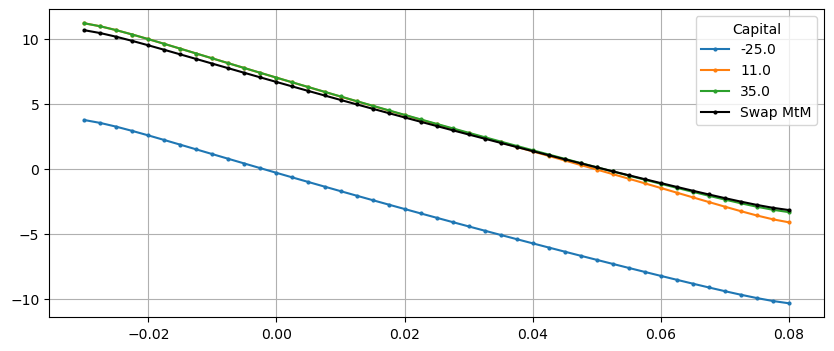

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(solver.r_grid, value_function[0, :, iy, 0], '-o', ms=2)
plt.plot(solver.r_grid, value_function[0, :, iy, iz], '-o', ms=2)
plt.plot(solver.r_grid, value_function[0, :, iy, -1], '-o', ms=2)
plt.plot(solver.r_grid, solver.params.q0 * solver.swap_mtm[0, :, iy, iz], '-o', ms=2, color='black')
plt.legend([*solver.k_grid[[0, iz, -1]], 'Swap MtM'], title='Capital')
plt.grid()
plt.show()

In [28]:
from tqdm.auto import tqdm

In [29]:
values = []
controls = []

for i, eps in enumerate(tqdm(eps_grid)):
    v, c = solvers[i].get_optimal_policy()
    values.append(v)
    controls.append(c)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

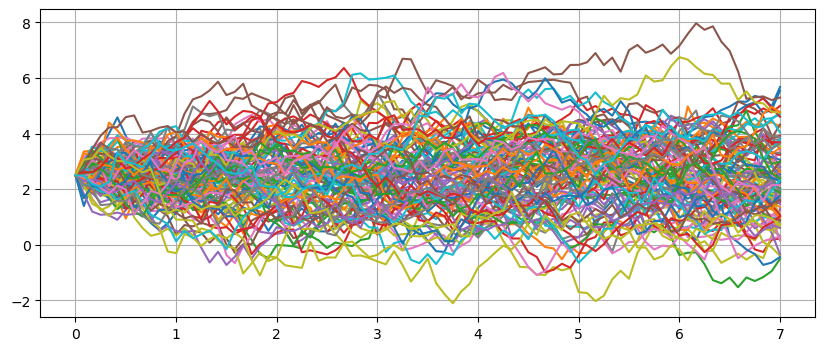

In [30]:
rates = solver.sample_rates(nsim=10_000)
plt.figure(figsize=(10, 4))
plt.plot(solver.timegrid, 100.0 * rates[:, :100])
plt.grid()
plt.show()

In [49]:
scenarios = []
for i, eps in enumerate(tqdm(eps_grid)):
    scenarios.append(solvers[i].get_scenario(rates, 100.0, solvers[i].params.K0, controls[i]))

  0%|          | 0/5 [00:00<?, ?it/s]

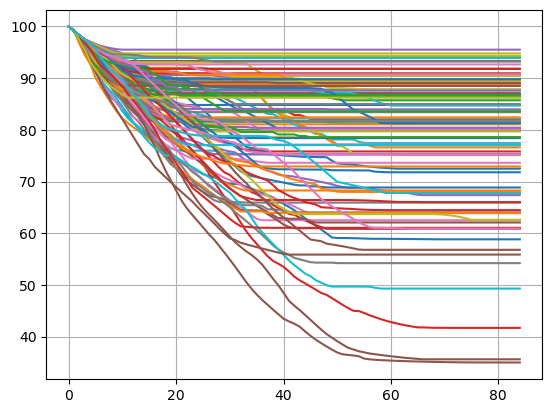

In [50]:
plt.plot(scenarios[0]['positions'][:, :100])
plt.grid()
plt.show()

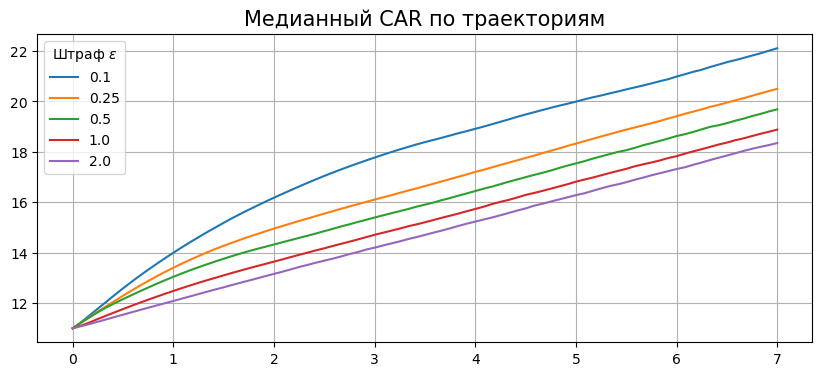

In [51]:
plt.figure(figsize=(10, 4))
plt.title("Медианный CAR по траекториям", fontsize=15)
for i, eps in enumerate((eps_grid)):
    plt.plot(solver.timegrid, 100 * np.median(scenarios[i]['CAR'], axis=1), label=eps)
plt.legend(title=r'Штраф $\varepsilon$')
plt.grid()
plt.show()

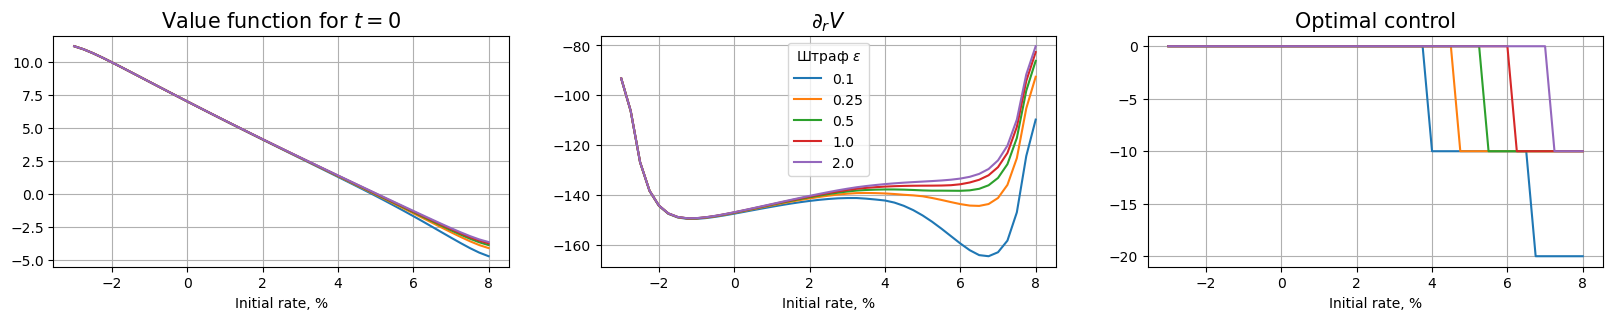

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(20, 3))

ax[0].set_title(r"Value function for $t = 0$", fontsize=15)
for i, eps in enumerate((eps_grid)):
    ax[0].plot(100.0 * solver.r_grid, values[i][0, :, iy, iz], label=eps)
ax[0].set_xlabel("Initial rate, %")
ax[0].grid()


ax[1].set_title(r"$\partial_r V$", fontsize=15)
for i, eps in enumerate((eps_grid)):
    grad = np.gradient(values[i][0, :, iy, iz], solver.r_grid)
    ax[1].plot(100.0 * solver.r_grid, grad, label=eps)
ax[1].set_xlabel("Initial rate, %")
ax[1].legend(title=r'Штраф $\varepsilon$')
ax[1].grid()

ax[2].set_title(r"Optimal control", fontsize=15)
for i, eps in enumerate((eps_grid)):
    ax[2].plot(100.0 * solver.r_grid, controls[i][0, :, iy, iz], label=eps)
ax[2].set_xlabel("Initial rate, %")
ax[2].grid()


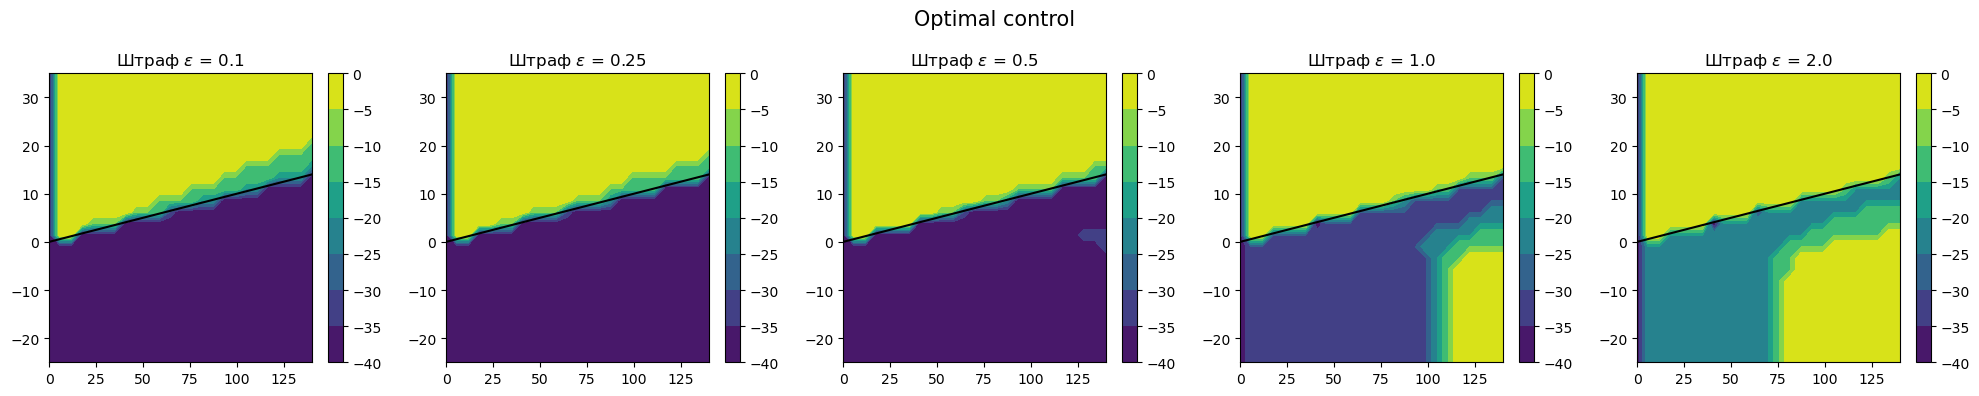

In [48]:
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
plt.suptitle("Optimal control", fontsize=15)
for i in range(5):
    ax[i].set_title(fr"Штраф $\varepsilon$ = {eps_grid[i]}")
    cf = ax[i].contourf(solver.q_grid, solver.k_grid, controls[i][0, ix].T)
    ax[i].plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black')
    plt.colorbar(cf, ax=ax[i])
fig.tight_layout()
plt.show()

In [12]:
zero_control = np.zeros_like(optimal_control)
car_control_v1  = np.zeros_like(optimal_control)
car_control_v2  = np.zeros_like(optimal_control)

u_bar = 10.0

for t in tqdm(range(solver.params.N)):
    ind = ((solver.k_mesh / solver.q_mesh.clip(0.01)) > solver.params.CAR).astype(float)
    sgn = 2.0 * ind - 1
    car_control_v1[t] = sgn * u_bar
    
    qn = solver.get_next_position(solver.q_mesh, u_bar)
    delta_K = solver.get_delta_K_on_grid(t, u_bar)
    Kn = solver.k_mesh + delta_K
    ind_next = ((Kn / qn.clip(0.01)) > solver.params.CAR).astype(float)    
    car_control_v2[t] = ind_next * u_bar - u_bar * (1 - ind_next) * (1 - ind)

  0%|          | 0/84 [00:00<?, ?it/s]

In [14]:
value_car_v1 = solver.get_value(car_control_v1)
value_car_v2 = solver.get_value(car_control_v2)

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

## Нормировать метрики на горизонт. Как нормировать Value? На аннуитет, расчитанный при условии постоянной ставки.

## Fast 1dim reval for swap

## Графики метрик + dX/dr в разных осях

## Динамика метрик на сценариях при постоянной политике ...

## Динамика метрики на сценариях при оптимальной политике ...

## Перфоманс оптимальной/псевдо-оптимальных политик на монте-карло, гистограммы кэшфлоу, распределение потоков. разделение потоков на купон/ликвидность/штраф/трейд

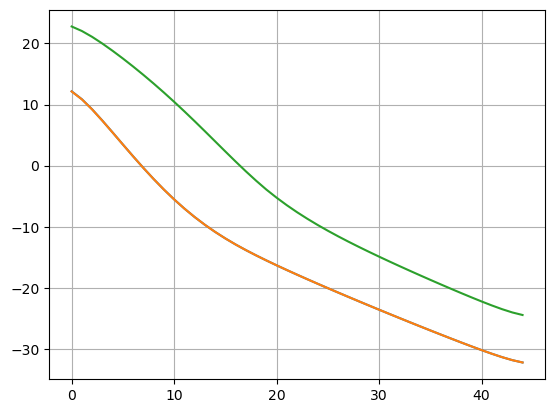

In [15]:
plt.plot(value_car_v1[0, :, ix, iy - 5])
plt.plot(value_car_v2[0, :, ix, iy - 5])
plt.plot(value_function[0, :, ix, iy - 5])
plt.grid()
plt.show()

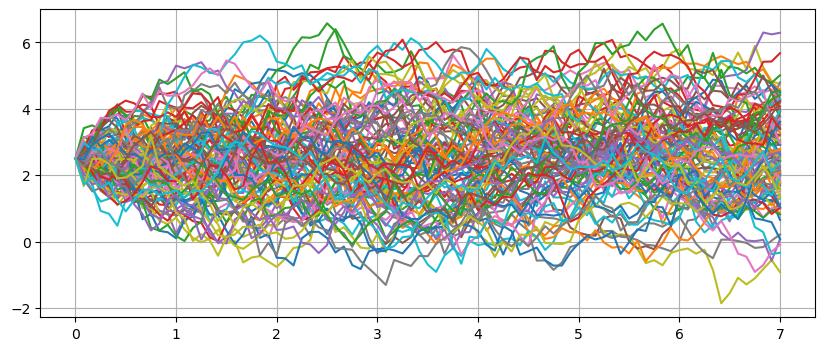

In [34]:
rates = solver.sample_rates(nsim=10_000)
plt.figure(figsize=(10, 4))
plt.plot(solver.timegrid, 100.0 * rates[:, :100])
plt.grid()
plt.show()

In [40]:
scenario_optimal = solver.get_scenario(rates, solver.params.q0, solver.params.K0, optimal_control)

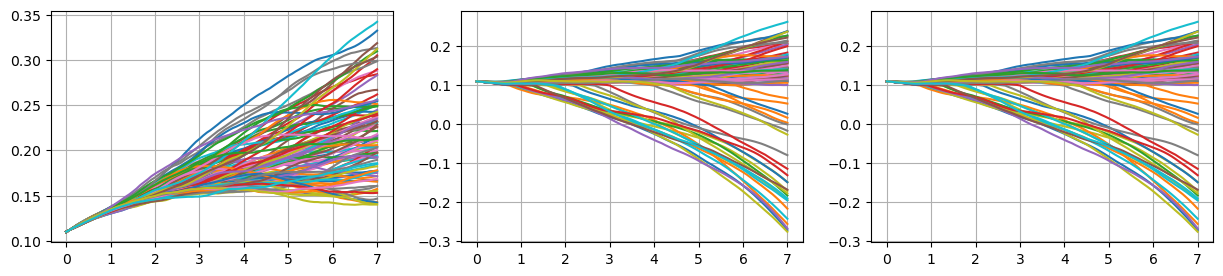

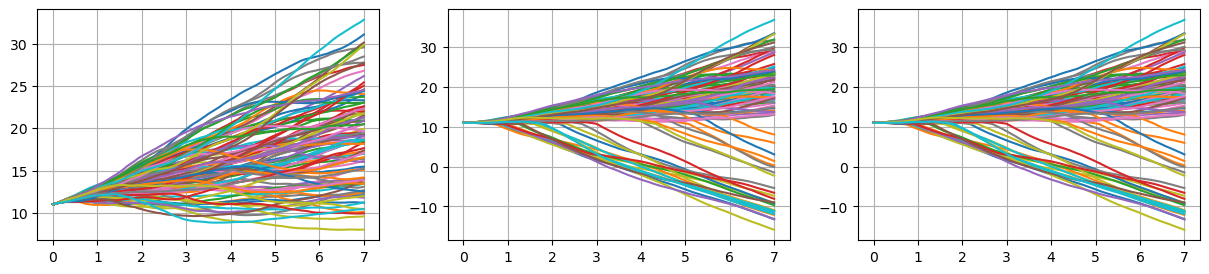

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].plot(solver.timegrid, scenario_optimal['CAR'][:, :100])
ax[0].grid()

ax[1].plot(solver.timegrid, scenario_car_v1['CAR'][:, :100])
ax[1].grid()

ax[2].plot(solver.timegrid, scenario_car_v2['CAR'][:, :100])
ax[2].grid()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].plot(solver.timegrid, scenario_optimal['capital'][:, :100])
ax[0].grid()

ax[1].plot(solver.timegrid, scenario_car_v1['capital'][:, :100])
ax[1].grid()

ax[2].plot(solver.timegrid, scenario_car_v2['capital'][:, :100])
ax[2].grid()
plt.show()

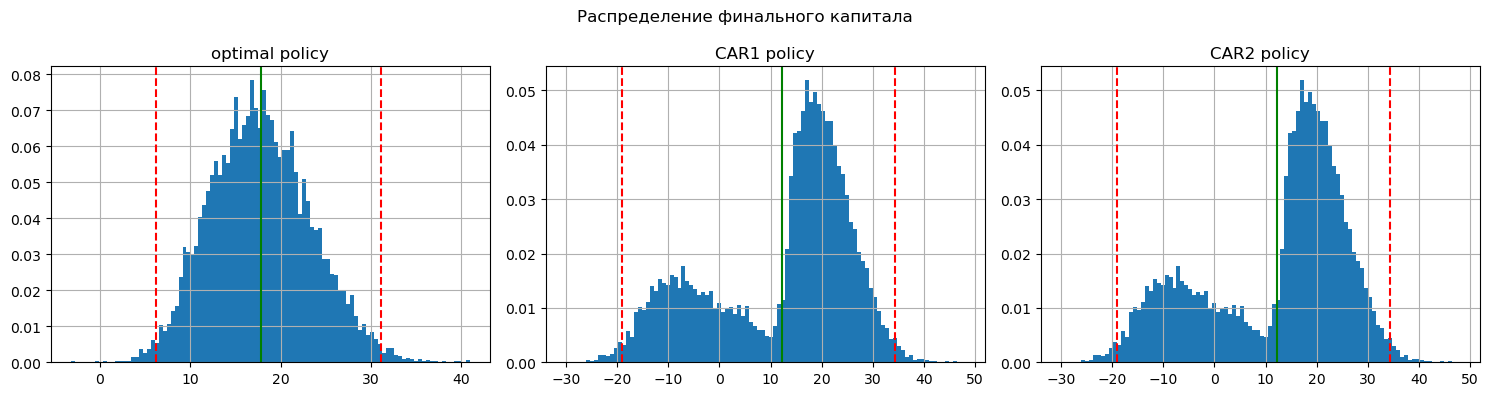

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plt.suptitle('Распределение финального капитала')
ax[0].set_title('optimal policy')
ax[0].hist(scenario_optimal['capital'][-1], bins='sqrt', density=True)
ax[0].axvline(scenario_optimal['capital'][-1].mean(), color='green')
ax[0].axvline(np.quantile(scenario_optimal['capital'][-1], 0.01), linestyle='--', color='red')
ax[0].axvline(np.quantile(scenario_optimal['capital'][-1], 0.99), linestyle='--', color='red')
ax[0].grid()


ax[1].set_title('CAR1 policy')
ax[1].hist(scenario_car_v1['capital'][-1], bins='sqrt', density=True)
ax[1].axvline(scenario_car_v1['capital'][-1].mean(), color='green')
ax[1].axvline(np.quantile(scenario_car_v1['capital'][-1], 0.01), linestyle='--', color='red')
ax[1].axvline(np.quantile(scenario_car_v1['capital'][-1], 0.99), linestyle='--', color='red')
ax[1].grid()


ax[2].set_title('CAR2 policy')
ax[2].hist(scenario_car_v2['capital'][-1], bins='sqrt', density=True)
ax[2].axvline(scenario_car_v2['capital'][-1].mean(), color='green')
ax[2].axvline(np.quantile(scenario_car_v2['capital'][-1], 0.01), linestyle='--', color='red')
ax[2].axvline(np.quantile(scenario_car_v2['capital'][-1], 0.99), linestyle='--', color='red')
ax[2].grid()
fig.tight_layout()
plt.show()

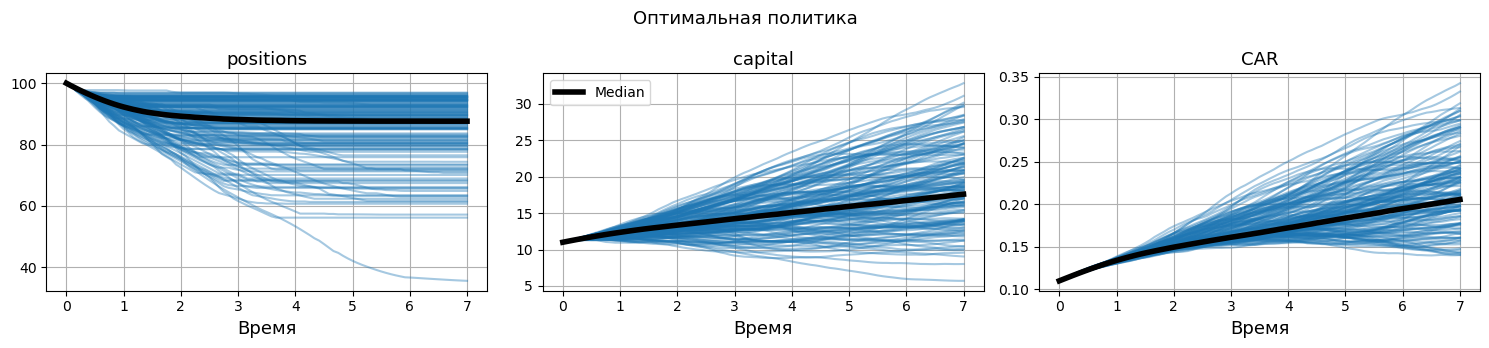

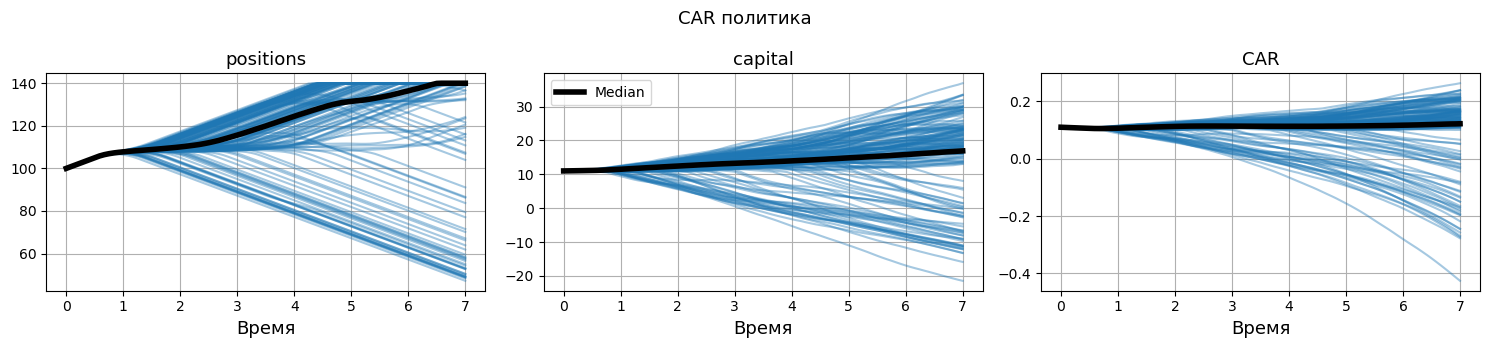

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
plt.suptitle("Оптимальная политика", fontsize=13)
titles = ['positions', 'capital', 'CAR']
for i, title in enumerate(titles):
    ax[i].plot(solver.timegrid, scenario_optimal[title][:, :150], color='tab:blue', alpha=0.4)
    ax[i].plot(solver.timegrid, np.median(scenario_optimal[title], axis=1), color='black', lw=4, label='Median')
    ax[i].grid()
    ax[i].set_xlabel("Время", fontsize=13)
    ax[i].set_title(title, fontsize=13)
ax[1].legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
plt.suptitle("CAR политика", fontsize=13)
titles = ['positions', 'capital', 'CAR']
for i, title in enumerate(titles):
    ax[i].plot(solver.timegrid, scenario_car_v2[title][:, :150], color='tab:blue', alpha=0.4)
    ax[i].plot(solver.timegrid, np.median(scenario_car_v2[title], axis=1), color='black', lw=4, label='Median')
    ax[i].grid()
    ax[i].set_xlabel("Время", fontsize=13)
    ax[i].set_title(title, fontsize=13)
ax[1].legend()
fig.tight_layout()
plt.show()

In [39]:
metrics = {}
horizonts = [0.5, 1.0, 2.0, 3.0]

for h in tqdm(horizonts):
    metrics[f'delta_capital_{h}_zero_policy'] = solver.get_capital(zero_control, h) / h
    metrics[f'delta_capital_{h}_bar_zero_policy'] = solver.get_capital_bar(zero_control, h) / h

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

In [191]:
for h in tqdm(horizonts):
    metrics[f'delta_capital_{h}_optimal_policy'] = get_capital(optimal_control, h) / h
    metrics[f'delta_capital_{h}_bar_optimal_policy'] = get_capital_bar(optimal_control, h) / h

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

In [96]:
timegrid = np.arange(solver.params.N + 1) * solver.params.dt
discounts = np.exp(-timegrid * solver.params.rbar)
annuity = discounts[1:].sum() * solver.params.dt
metrics['value'] = value_function.copy() / annuity
metrics['MtM'] = gpt_model.SWAP_MTM * solver.q_mesh / annuity

In [193]:
def plot_metric(metrics, policy, horizonts, suptitle, ix, iy, iz):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    plt.suptitle(suptitle, fontsize=15)
    for i, h in enumerate(horizonts):
        k = f'delta_capital_{h}_{policy}'
        ax[0].plot(100.0 * solver.r_grid, metrics[k][0, :, iy, iz], color=f'C{i}')
        ax[1].plot(solver.q_grid, metrics[k][0, ix, :, iz], color=f'C{i}', label=f'Capital {h}Y')
        ax[2].plot(solver.k_grid, metrics[k][0, ix, iy, :], color=f'C{i}')
        k = f'delta_capital_{h}_bar_{policy}'
        ax[0].plot(100.0 * solver.r_grid, metrics[k][0, :, iy, iz], '--', color=f'C{i}')
        ax[1].plot(solver.q_grid, metrics[k][0, ix, :, iz], '--', color=f'C{i}')
        ax[2].plot(solver.k_grid, metrics[k][0, ix, iy, :], '--', color=f'C{i}')
        
    ax[0].plot(100.0 * solver.r_grid, metrics['value'][0, :, iy, iz], color='black')
    ax[1].plot(solver.q_grid, metrics['value'][0, ix, :, iz], color='black', label='value')
    ax[2].plot(solver.k_grid, metrics['value'][0, ix, iy, :], color='black')
    
    ax[0].plot(100.0 * solver.r_grid, metrics['MtM'][0, :, iy, iz], color='magenta')
    ax[1].plot(solver.q_grid, metrics['MtM'][0, ix, :, iz], color='magenta', label='MtM')
    ax[2].plot(solver.k_grid, metrics['MtM'][0, ix, iy, :], color='magenta')
    
    ax[0].set_xlabel('Rate', fontsize=12)
    ax[1].set_xlabel('Position', fontsize=12)
    ax[2].set_xlabel('Capital', fontsize=12)
    ax[1].legend(fontsize=12)
    for i in range(3):
        ax[i].grid()
    fig.tight_layout()
    plt.show()

In [194]:
deltas = {k : np.gradient(v, solver.r_grid, axis=1) for k, v in metrics.items()}

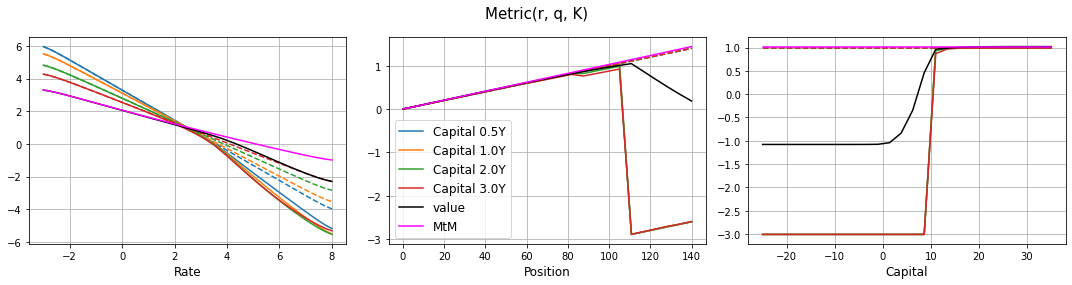

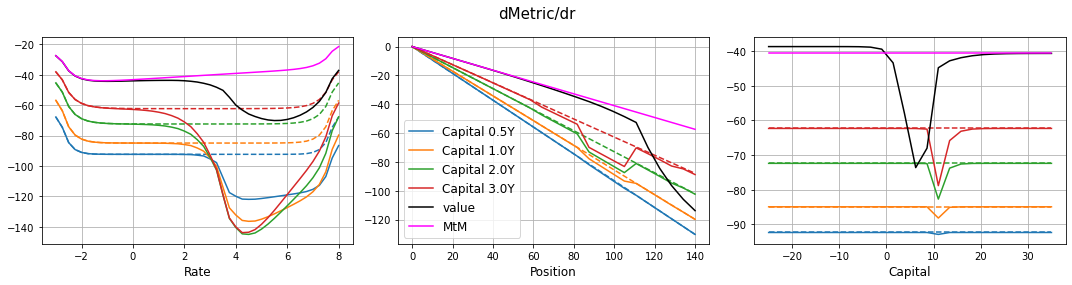

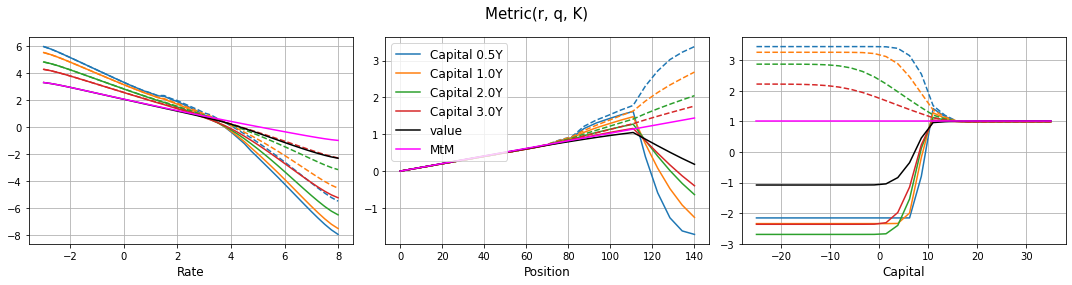

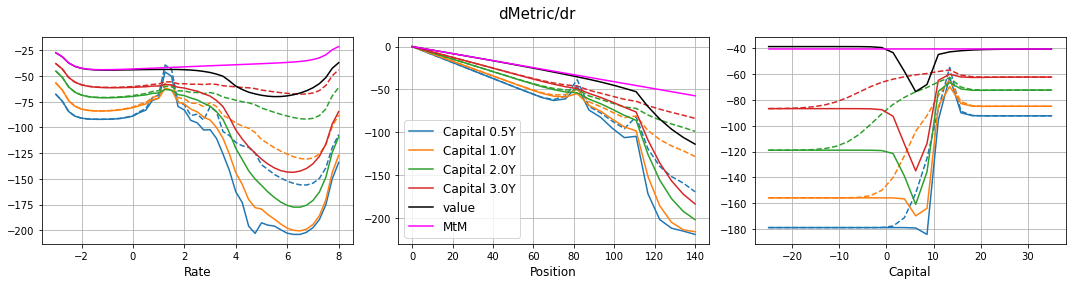

In [196]:
plot_metric(metrics, 'zero_policy', horizonts, 'Metric(r, q, K)', ix, iy, iz)
plot_metric(deltas, 'zero_policy', horizonts, 'dMetric/dr', ix, iy, iz)

plot_metric(metrics, 'optimal_policy', horizonts, 'Metric(r, q, K)', ix, iy, iz)
plot_metric(deltas,  'optimal_policy', horizonts, 'dMetric/dr', ix, iy, iz)

In [204]:
def interpolate_on_scenario(scenario, metric):
    nt = len(scenario['rate']) - 1    
    res = {}
    for k, v in tqdm(metric.items()):
        res[k] = np.zeros_like(scenario['rate'])
        for i in range(nt):
            res[k][i] = gpt_model.interp3_uniform(v[i], 
                                                  scenario['rate'][i], 
                                                  scenario['positions'][i], 
                                                  scenario['capital'][i]
                                                 )
    return res

In [205]:
scenario_zero_policy = gpt_model.get_scenario(rate, solver.params.q0, solver.params.K0, zero_control)

  0%|          | 0/18 [00:00<?, ?it/s]

In [206]:
metric_traj_optimal_policy = interpolate_on_scenario(scenario, metrics)
deltas_traj_optimal_policy = interpolate_on_scenario(scenario, deltas)
metric_traj_zero_policy = interpolate_on_scenario(scenario_zero_policy, metrics)
deltas_traj_zero_policy = interpolate_on_scenario(scenario_zero_policy, deltas)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

In [219]:
metric_traj_optimal_policy.keys()

dict_keys(['delta_capital_0.5_zero_policy', 'delta_capital_0.5_bar_zero_policy', 'delta_capital_1.0_zero_policy', 'delta_capital_1.0_bar_zero_policy', 'delta_capital_2.0_zero_policy', 'delta_capital_2.0_bar_zero_policy', 'delta_capital_3.0_zero_policy', 'delta_capital_3.0_bar_zero_policy', 'value', 'MtM', 'delta_capital_0.5_optimal_policy', 'delta_capital_0.5_bar_optimal_policy', 'delta_capital_1.0_optimal_policy', 'delta_capital_1.0_bar_optimal_policy', 'delta_capital_2.0_optimal_policy', 'delta_capital_2.0_bar_optimal_policy', 'delta_capital_3.0_optimal_policy', 'delta_capital_3.0_bar_optimal_policy'])

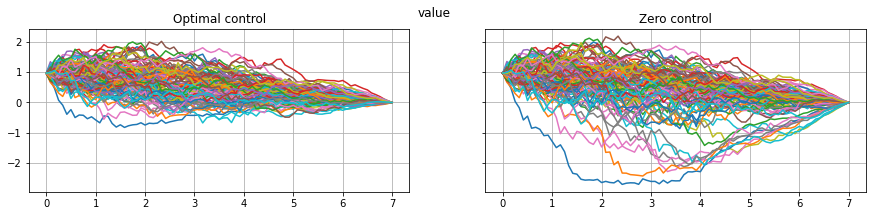

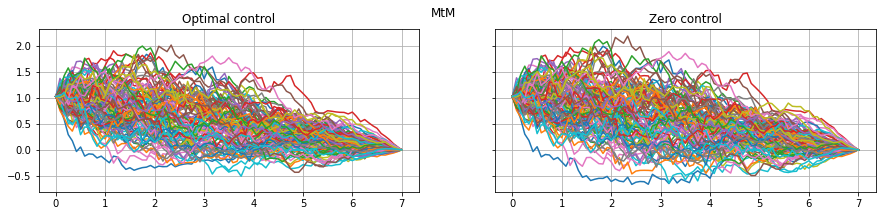

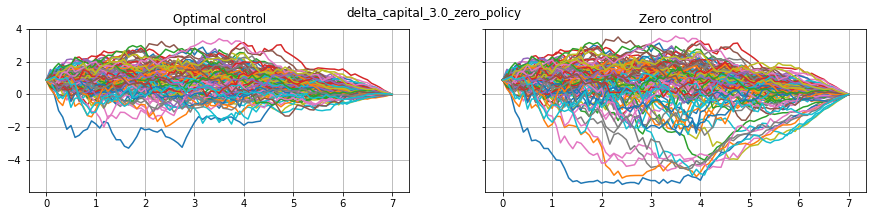

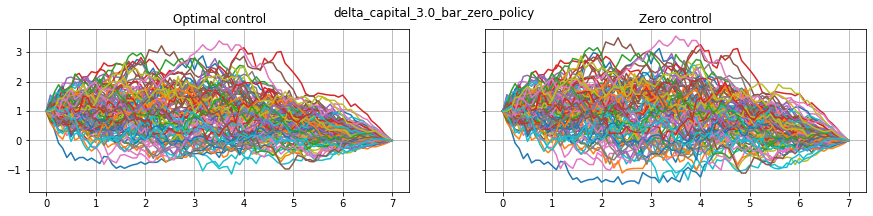

In [227]:
suptitles = ['value', 'MtM', 'delta_capital_3.0_zero_policy', 'delta_capital_3.0_bar_zero_policy']

for sup in suptitles:
    fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True)
    plt.suptitle(sup)
    ax[0].set_title("Optimal control")
    ax[0].plot(timegrid, metric_traj_optimal_policy[sup][:, :100])
    ax[0].grid()

    ax[1].set_title("Zero control")
    ax[1].plot(timegrid, metric_traj_zero_policy[sup][:, :100])
    ax[1].grid()
    plt.show()

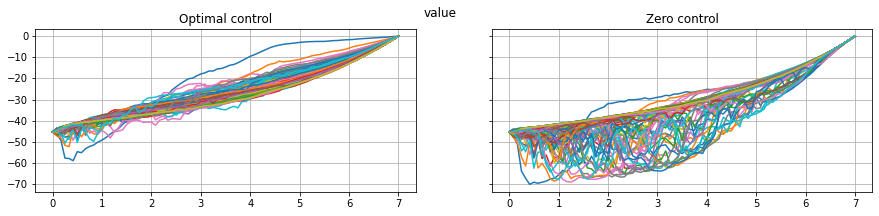

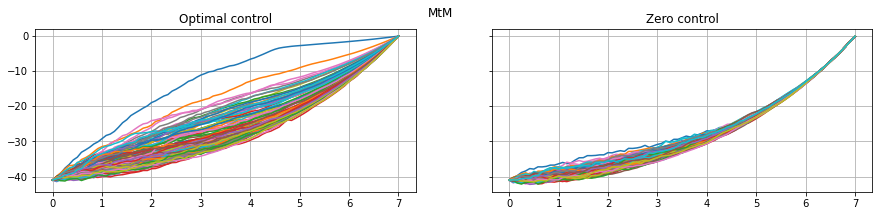

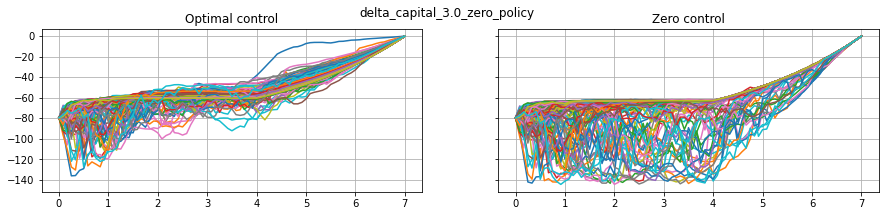

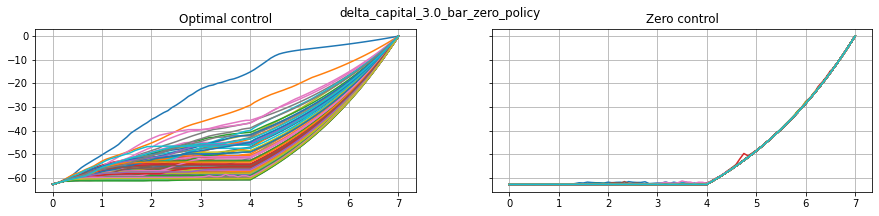

In [228]:
suptitles = ['value', 'MtM', 'delta_capital_3.0_zero_policy', 'delta_capital_3.0_bar_zero_policy']

for sup in suptitles:
    fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True)
    plt.suptitle(sup)
    ax[0].set_title("Optimal control")
    ax[0].plot(timegrid, deltas_traj_optimal_policy[sup][:, :100])
    ax[0].grid()

    ax[1].set_title("Zero control")
    ax[1].plot(timegrid, deltas_traj_zero_policy[sup][:, :100])
    ax[1].grid()
    plt.show()

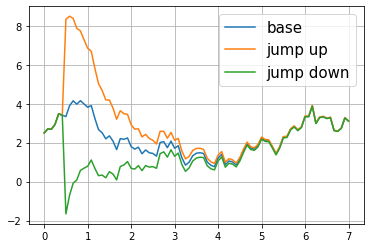

In [237]:
nt = solver.params.N
timegrid = np.arange(nt + 1) * solver.params.dt
np.random.seed(42)
shocks = np.random.randn(nt)
shocks = shocks - shocks.mean()

base_scen = np.zeros(nt + 1)
base_scen[0] = solver.params.rbar

for t in range(nt):
    base_scen[t + 1] = solver.params.rbar + solver.paramsHI * (base_scen[t] - solver.params.rbar) + gpt_model.BASE_SD * shocks[t]
    
jump_phi = np.exp(-1.0 * solver.params.dt)
jump_size = 0.05
jump_index = 5

jump_traj = np.zeros(nt + 1)
for t in range(nt):
    jump_traj[t + 1] = jump_traj[t] * jump_phi + jump_size * (jump_index == t)
jump_up_scen = base_scen + jump_traj
jump_down_scen = base_scen - jump_traj
plt.plot(timegrid, 100 * base_scen)
plt.plot(timegrid, 100 * jump_up_scen)
plt.plot(timegrid, 100 * jump_down_scen)
plt.legend(['base', 'jump up', 'jump down'], fontsize=15)
plt.grid()
plt.show()

In [ ]:
scenario_base_zero = gpt_model.get_scenario(base_scen, solver.params.q0, solver.params.K0, zero_control)
scenario_base_zero = gpt_model.get_scenario(base_scen, solver.params.q0, solver.params.K0, zero_control)

In [ ]:
    
scen = gpt_model.get_scenario(rate, solver.params.q0 + 20, solver.params.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(solver.params.CAR, color='black')
plt.show()


plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

In [ ]:
nt = solver.params.N
timegrid = np.arange(nt + 1) * solver.params.dt

nt = solver.params.N
np.random.seed(42)
shocks = np.random.randn(nt)
shocks = shocks - shocks.mean()

rate = np.zeros(nt + 1)
rate[0] = solver.params.rbar
for t in range(nt):
    rate[t + 1] = solver.params.rbar + solver.paramsHI * (rate[t] - solver.params.rbar) + gpt_model.BASE_SD * shocks[t]
    
scen = gpt_model.get_scenario(rate, solver.params.q0 + 20, solver.params.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(solver.params.CAR, color='black')
plt.show()


plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

In [ ]:
assert False

In [ ]:
horizonts_years = [0.5, 1, 2, 3]
metrics = {}
controls = {}
deltas = {}
metrics['value'], controls['value'] = gpt_model.get_optimal_policy()
for h in horizonts_years:
    h_int = int(h / solver.params.dt)
    metrics[f'capital_{h}'], controls[f'capital_{h}'] = gpt_model.get_optimal_policy_capital(h_int)
for k, v in metrics.items():
    deltas[k] = np.gradient(v, solver.r_grid, axis=1)

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
plt.figure(figsize=(5,2))
plt.title("dV_dr")
for k, v in deltas.items():
    plt.plot(100 * solver.r_grid, v[0, :, 20, 16], label=k)
plt.legend()
plt.xlabel("Rate, %")
plt.show()

plt.figure(figsize=(5,2))
for k, v in metrics.items():
    plt.plot(100 * solver.r_grid, v[0, :, 20, 16], label=k)
plt.legend()
plt.xlabel("Rate, %")
plt.show()

In [ ]:
controls['zero'] = np.zeros_like(controls['value'])

In [ ]:
values = {}

for k, control in controls.items():
    values[k] = gpt_model.get_value(control)

In [ ]:
ix = np.argmin(np.abs(solver.params.rbar - solver.r_grid))
iy = np.argmin(np.abs(solver.params.q0 - solver.q_grid))
iz = np.argmin(np.abs(solver.params.K0 - solver.k_grid))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].set_title("Value для разных политик", fontsize=10)
for k, v in values.items():
    ax[0].plot(100 * solver.r_grid, v[0, :, iy, iz],label=k)
ax[0].set_xlabel("Rate, %")
ax[1].set_xlabel("Rate, %")
ax[2].set_xlabel("Rate, %")

ax[1].set_title("dV_dr для разных политик", fontsize=10)
for k, v in values.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    ax[1].plot(100 * solver.r_grid, dv_dr[0, :, iy, iz],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(100 * solver.r_grid, u[0, :, iy, iz],label=k)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].set_title("Value для разных политик", fontsize=10)
for k, v in values.items():
    ax[0].plot(solver.q_grid, v[0, ix, :, iz],label=k)
ax[0].set_xlabel("Position, q")
ax[1].set_xlabel("Position, q")
ax[2].set_xlabel("Position, q")

ax[1].set_title("dV_dr для разных политик", fontsize=10)
for k, v in values.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    ax[1].plot(solver.q_grid, dv_dr[0, ix, :, iz],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(solver.q_grid, u[0, ix, :, iz],label=k)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].set_title("Value для разных политик", fontsize=10)
for k, v in values.items():
    ax[0].plot(solver.k_grid, v[0, ix, iy, :],label=k)
ax[0].set_xlabel("Capital, K")
ax[1].set_xlabel("Capital, K")
ax[2].set_xlabel("Capital, K")

ax[1].set_title("dV_dr для разных политик", fontsize=10)
for k, v in values.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    ax[1].plot(solver.k_grid, dv_dr[0, ix, iy, :],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(solver.k_grid, u[0, ix, iy, :],label=k)
fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plt.suptitle("Разные метрики на естественных политиках", fontsize=15)
ax[0].set_title("Метрика X", fontsize=10)
for k, v in metrics.items():
    ax[0].plot(100 * solver.r_grid, v[0, :, iy, iz],label=k)
ax[0].set_xlabel("Rate, %")
ax[1].set_xlabel("Rate, %")
ax[2].set_xlabel("Rate, %")

ax[1].set_title("Чувствительноть: dX_dr", fontsize=10)
scale = None
for k, v in metrics.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    scale = np.abs(dv_dr[0, ix, iy, iz])
    ax[1].plot(100 * solver.r_grid, dv_dr[0, :, iy, iz] / scale,label=f"{k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, v in metrics.items():
    ax[2].plot(100 * solver.r_grid, controls[k][0, :, iy, iz],label=k)
fig.tight_layout()
plt.show()

In [ ]:
control = controls['value'][0]
plt.figure(figsize=(10, 4))
plt.title("Оптимальная политика (value)")
cf = plt.contourf(solver.q_grid, solver.k_grid, control[ix].T, alpha=0.6)
plt.contour(solver.q_grid, solver.k_grid, control[ix].T)
plt.plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
plt.colorbar(cf, label='Значения')
plt.show()

control = controls['capital_1'][0]
plt.figure(figsize=(10, 4))
plt.title("Оптимальная политика (капитал 1Y)")
cf = plt.contourf(solver.q_grid, solver.k_grid, control[ix].T, alpha=0.6)
plt.contour(solver.q_grid, solver.k_grid, control[ix].T)
plt.plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
plt.colorbar(cf, label='Значения')
plt.show()

control = controls['capital_3'][0]
plt.figure(figsize=(10, 4))
plt.title("Оптимальная политика (капитал 3Y)")
cf = plt.contourf(solver.q_grid, solver.k_grid, control[ix].T, alpha=0.6)
plt.contour(solver.q_grid, solver.k_grid, control[ix].T)
plt.plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
plt.colorbar(cf, label='Значения')
plt.show()

In [ ]:
nt = solver.params.N
timegrid = np.arange(nt + 1) * solver.params.dt

In [ ]:
nt = solver.params.N
np.random.seed(42)
shocks = np.random.randn(nt)
shocks = shocks - shocks.mean()

rate = np.zeros(nt + 1)
rate[0] = solver.params.rbar
for t in range(nt):
    rate[t + 1] = solver.params.rbar + solver.paramsHI * (rate[t] - solver.params.rbar) + gpt_model.BASE_SD * shocks[t]
    
scen = gpt_model.get_scenario(rate, solver.params.q0 + 20, solver.params.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(solver.params.CAR, color='black')
plt.show()


plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

In [ ]:
jump_phi = np.exp(-1.0 * solver.params.dt)

jump_size = 0.05
jump_index = 5

jump_traj = np.zeros(nt + 1)
for t in range(nt):
    jump_traj[t + 1] = jump_traj[t] * jump_phi + jump_size * (jump_index == t)
    
    
scen = gpt_model.get_scenario((rate + jump_traj), solver.params.q0 + 10, solver.params.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
metrics_scen = {}
control_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    metrics_scen[k] = np.zeros(nt + 1)
    control_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])
        metrics_scen[k][t] = gpt_model.interp3_uniform(metrics[k][t], *scen_vec[t])
        control_scen[k][t] = gpt_model.interp3_uniform(controls[k][t], *scen_vec[t])
        
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(solver.params.CAR, color='black')
plt.show()

timegrid = np.arange(nt + 1) * solver.params.dt
plt.figure(figsize=(10, 3.5))
for k, d in metrics_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask], label=k)
plt.legend()
plt.show()

timegrid = np.arange(nt + 1) * solver.params.dt
plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

timegrid = np.arange(nt + 1) * solver.params.dt
plt.figure(figsize=(10, 3.5))
for k, d in control_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask], label=k)
plt.legend()
plt.show()

In [ ]:
jump_size = -0.05
jump_traj = np.zeros(nt + 1)
for t in range(nt):
    jump_traj[t + 1] = jump_traj[t] * jump_phi + jump_size * (jump_index == t)
    
scen = gpt_model.get_scenario((rate + jump_traj), solver.params.q0 + 10, solver.params.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
metrics_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    metrics_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])
        metrics_scen[k][t] = gpt_model.interp3_uniform(metrics[k][t], *scen_vec[t])
        
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(solver.params.CAR, color='black')
plt.show()

timegrid = np.arange(nt + 1) * solver.params.dt
plt.figure(figsize=(10, 3.5))
for k, d in metrics_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask], label=k)
plt.legend()
plt.show()

timegrid = np.arange(nt + 1) * solver.params.dt
plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

In [ ]:
value = metrics['value'][0]
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i, rate_index in enumerate([10, 22, 32]):
    #plt.figure(figsize=(10, 4))
    ax[i].set_title(f"Value, rate = {solver.r_grid[rate_index] * 100:0.2f}%")
    cf = ax[i].contourf(solver.q_grid, solver.k_grid, value[rate_index].T, alpha=0.6)
    ax[i].contour(solver.q_grid, solver.k_grid, value[rate_index].T)
    ax[i].plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
    plt.colorbar(cf, ax=ax[i])
plt.show()

value = controls['value'][0]
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i, rate_index in enumerate([10, 22, 32]):
    #plt.figure(figsize=(10, 4))
    ax[i].set_title(f"Control, rate = {solver.r_grid[rate_index] * 100:0.2f}%")
    cf = ax[i].contourf(solver.q_grid, solver.k_grid, value[rate_index].T, alpha=0.6)
    ax[i].contour(solver.q_grid, solver.k_grid, value[rate_index].T)
    ax[i].plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
    plt.colorbar(cf, ax=ax[i])
plt.show()

In [ ]:
value = deltas['value'][0]
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for i, rate_index in enumerate([10, 22, 32]):
    ax[i].set_title(f"Rate={100* solver.r_grid[rate_index] : 0.2f}%")
    ax[i].plot(solver.q_grid, value[rate_index, :, ::10])
    ax[i].set_xlabel("Position, q")
ax[1].legend(solver.k_grid[::10].round(2))
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for i, rate_index in enumerate([10, 22, 32]):
    ax[i].set_title(f"Rate={100* solver.r_grid[rate_index] : 0.2f}%")
    ax[i].plot(solver.k_grid, value[rate_index,  ::10].T)
    ax[i].set_xlabel("Capital, K")
ax[1].legend(solver.q_grid[::10].round(2))
fig.tight_layout()
plt.show()

In [ ]:
capitals = {}
for k, control in controls.items():
    capitals[k] = gpt_model.get_capital(control, 1.0)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].set_title("Capital1Y для разных политик", fontsize=10)
for k, v in capitals.items():
    ax[0].plot(100 * solver.r_grid, v[0, :, iy, iz],label=k)
ax[0].set_xlabel("Rate, %")
ax[1].set_xlabel("Rate, %")
ax[2].set_xlabel("Rate, %")

ax[1].set_title("dCapital1Y_dr для разных политик", fontsize=10)
for k, v in capitals.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    ax[1].plot(100 * solver.r_grid, dv_dr[0, :, iy, iz],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(100 * solver.r_grid, u[0, :, iy, iz],label=k)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].set_title("Capital1Y для разных политик", fontsize=10)
for k, v in capitals.items():
    ax[0].plot(solver.q_grid, v[0, ix, :, iz],label=k)
ax[0].set_xlabel("Position, q")
ax[1].set_xlabel("Position, q")
ax[2].set_xlabel("Position, q")

ax[1].set_title("dCapital1Y_dr для разных политик", fontsize=10)
for k, v in capitals.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    ax[1].plot(solver.q_grid, dv_dr[0, ix, :, iz],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(solver.q_grid, u[0, ix, :, iz],label=k)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].set_title("Capital1Y для разных политик", fontsize=10)
for k, v in capitals.items():
    ax[0].plot(solver.k_grid, v[0, ix, iy, :],label=k)
ax[0].set_xlabel("Capital, K")
ax[1].set_xlabel("Capital, K")
ax[2].set_xlabel("Capital, K")

ax[1].set_title("dCapital1Y_dr для разных политик", fontsize=10)
for k, v in capitals.items():
    dv_dr = np.gradient(v, solver.r_grid, axis=1)
    ax[1].plot(solver.k_grid, dv_dr[0, ix, iy, :],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(solver.k_grid, u[0, ix, iy, :],label=k)
fig.tight_layout()
plt.show()

In [ ]:
zero_capital = gpt_model.get_capital(controls['zero'], 1.0 - 1/12)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
values.keys()

In [ ]:
controls['greedy'] = greedy_policy

In [ ]:
greedy_policy = np.zeros_like(zero_capital)
nt = solver.params.N

n_actions = len(solver.params.u_actions)
for t in tqdm(range(nt)):
    q_funtion = []
    # interating over policies
    for i, action in enumerate(solver.params.u_actions):    
        dK = gpt_model.stage_dK(solver.r_mesh, solver.q_mesh, solver.k_mesh, action)
        next_q = gpt_model.next_q(solver.q_mesh, action)
        next_K = solver.k_grid + dK
        continuation_value = gpt_model.diffuse(zero_capital[t + 1], next_q, next_K)
        q_funtion.append(dK + continuation_value)
    q_funtion = np.stack(q_funtion, axis=0)
    idx = np.argmax(q_funtion, axis=0)
    greedy_policy[t] = np.asarray(solver.params.u_actions)[idx]

In [ ]:
value = greedy_policy[0]
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i, rate_index in enumerate([10, 22, 32]):
    #plt.figure(figsize=(10, 4))
    ax[i].set_title(f"Control, rate = {solver.r_grid[rate_index] * 100:0.2f}%")
    cf = ax[i].contourf(solver.q_grid, solver.k_grid, value[rate_index].T, alpha=0.6)
    ax[i].contour(solver.q_grid, solver.k_grid, value[rate_index].T)
    ax[i].plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
    plt.colorbar(cf, ax=ax[i])
plt.show()

In [ ]:
values['greedy'] = gpt_model.get_value(greedy_policy)

In [ ]:
value = values['greedy'][0]
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i, rate_index in enumerate([10, 22, 32]):
    #plt.figure(figsize=(10, 4))
    ax[i].set_title(f"Greedy value, rate = {solver.r_grid[rate_index] * 100:0.2f}%")
    cf = ax[i].contourf(solver.q_grid, solver.k_grid, value[rate_index].T, alpha=0.6)
    ax[i].contour(solver.q_grid, solver.k_grid, value[rate_index].T)
    ax[i].plot(solver.q_grid, solver.q_grid * solver.params.CAR, color='black', lw=5)
    plt.colorbar(cf, ax=ax[i])
plt.show()